# Feature engineering

Based on the EDA we can think of some new features and transformations that could be interesting for our model. In this notebook we play with this ideas

In [4]:
# We import the necessary libraries for data manipulation and analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../data/raw/heart_failure_clinical_records_dataset.csv')

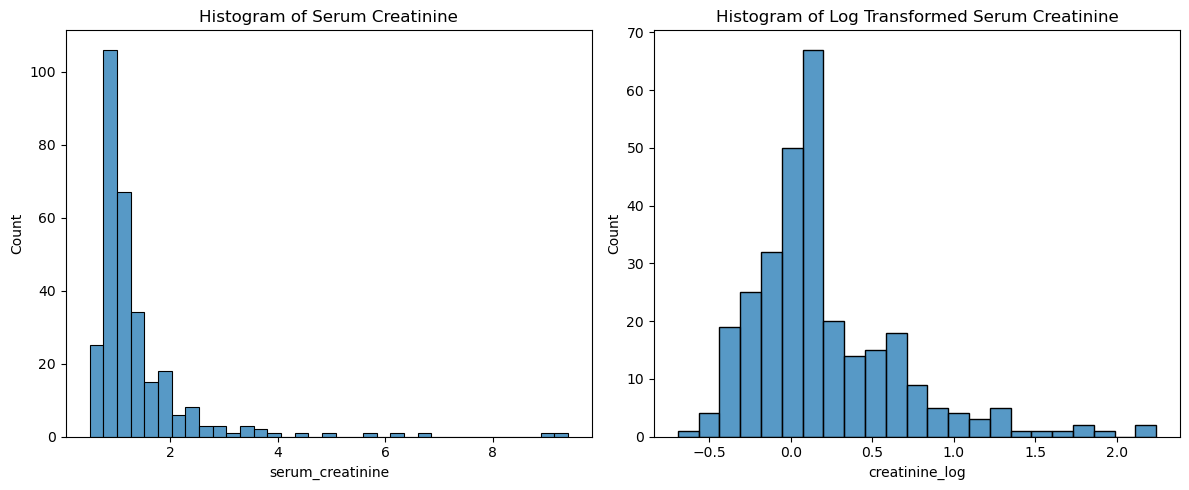

In [7]:
# We noticed that the serum creatinine variable is highly skewed, so we apply a log transformation to it and visualize the distribution again
# And we put them side by side to compare the distribution before and after the transformation

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["serum_creatinine"], ax=axes[0])
axes[0].set_title('Histogram of Serum Creatinine')

df["creatinine_log"] = np.log(df["serum_creatinine"])
sns.histplot(df["creatinine_log"], ax=axes[1])
axes[1].set_title('Histogram of Log Transformed Serum Creatinine')

plt.tight_layout()
plt.show()

We see that the transformed variable looks closer to a normal distribution. It is probably a good idea to do this change.

### Possible interactions between predictors
| Interaction Variable | Variables Involved | Clinical Intuition |
| :--- | :--- | :--- |
| **Age & Ejection Fraction** | `age` * `ejection_fraction` | Measures the combined physiological stress of an aging body paired with a weakened heart pump. |
| **Heart & Kidney Synergy** | `ejection_fraction` * `serum_creatinine` | Captures the "cardiorenal" connection; poor heart pump function often leads to decreased kidney perfusion. |
| **Age & Diabetes** | `age` * `diabetes` | Explores how the long-term metabolic damage caused by diabetes scales or worsens as a patient gets older. |
| **Sodium / Creatinine Ratio** | `serum_sodium` / `serum_creatinine` | Refines the measurement of kidney efficiency by balancing electrolyte levels against waste filtration markers. |

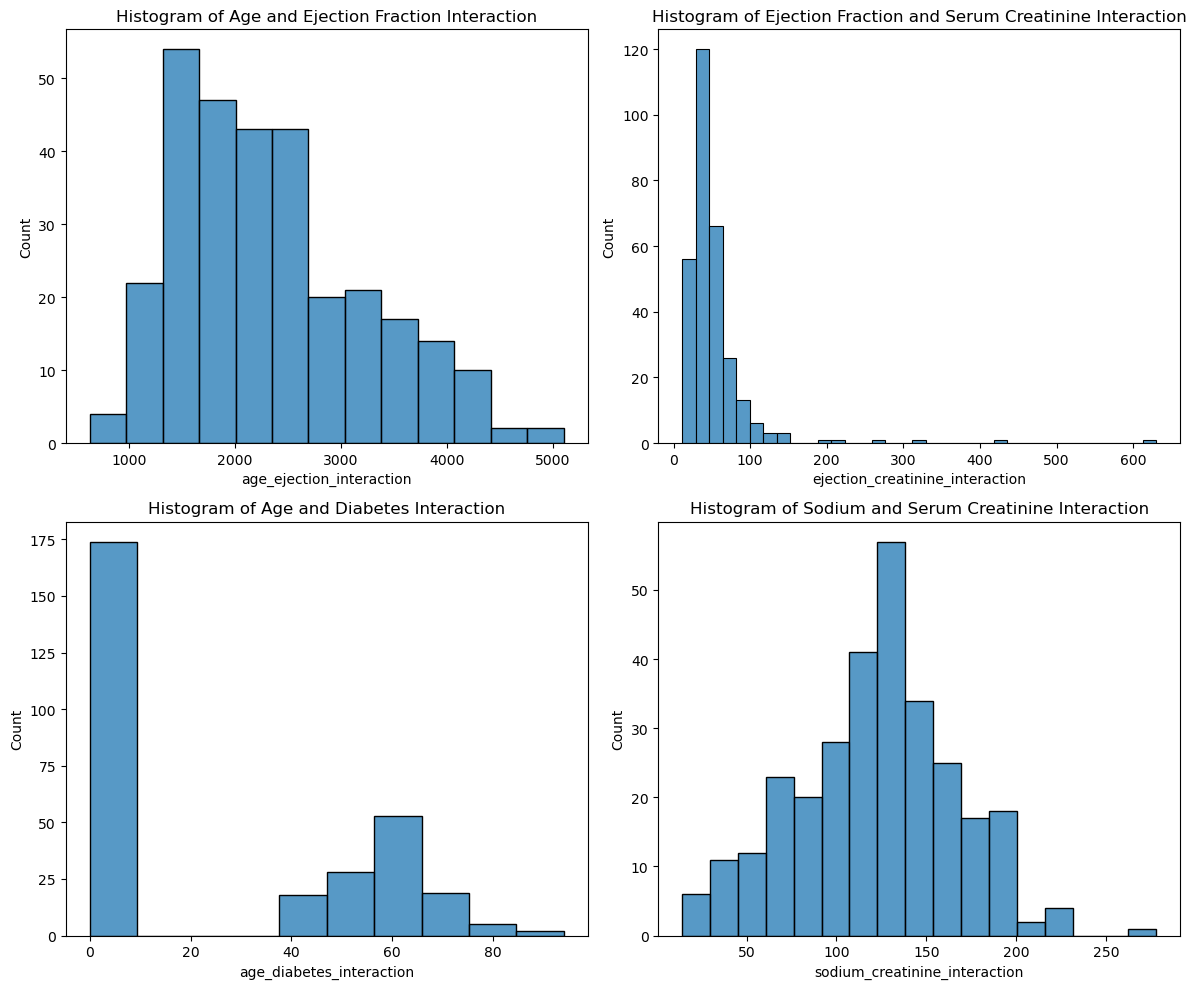

In [9]:
# We will create new features based on these interactions and visualize their distributions as well.

# Interactions between age and ejection fraction. 
df["age_ejection_interaction"] = df["age"] * df["ejection_fraction"]

# Interactions between ejection fraction and serum creatinine. 
df["ejection_creatinine_interaction"] = df["ejection_fraction"] * df["serum_creatinine"]

# Interactions between age and diabetes.
df["age_diabetes_interaction"] = df["age"] * df["diabetes"]

# Interaction between sodium and creatinine.
df["sodium_creatinine_interaction"] = df["serum_sodium"] / df["serum_creatinine"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df["age_ejection_interaction"], ax=axes[0, 0])
axes[0, 0].set_title('Histogram of Age and Ejection Fraction Interaction')
sns.histplot(df["ejection_creatinine_interaction"], ax=axes[0, 1])
axes[0, 1].set_title('Histogram of Ejection Fraction and Serum Creatinine Interaction')
sns.histplot(df["age_diabetes_interaction"], ax=axes[1, 0])
axes[1, 0].set_title('Histogram of Age and Diabetes Interaction')
sns.histplot(df["sodium_creatinine_interaction"], ax=axes[1, 1])
axes[1, 1].set_title('Histogram of Sodium and Serum Creatinine Interaction')
plt.tight_layout()
plt.show()